<a href="https://colab.research.google.com/github/Fillo468/Emotion-Recognition-Multimodal-Fusion-/blob/main/PREPROCESS_EMOVOME.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import Dataset**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import LabelEncoder
import os

from google.colab import drive
drive.mount('/content/drive')

# Labels and features are in different files
feat_path = "/content/drive/MyDrive/features_eGeMAPSv02.csv"
label_path = "/content/drive/MyDrive/labels.csv"

features_df = pd.read_csv(feat_path)
labels_df = pd.read_csv(label_path)

# Merging labels and features
df = pd.merge(features_df, labels_df, on='file_id')

Mounted at /content/drive


**Principal Feature Selection**

In [2]:
# Computing new target values
df['valence_num_C'] = df[['valence_NE1_SAM', 'valence_NE2_SAM', 'valence_NE3_SAM']].mean(axis=1)
df['arousal_num_C'] = df[['arousal_NE1_SAM', 'arousal_NE2_SAM', 'arousal_NE3_SAM']].mean(axis=1)

TARGETS = ["valence_num_C", "arousal_num_C"]
df = df.dropna(subset=TARGETS)

In [3]:
# Isolating audio columns (not selecting target ones)
label_cols = labels_df.columns.tolist()
feature_cols = [c for c in df.columns if c not in label_cols and c not in TARGETS]

# Filling empty cells with the median of single columns
X = df[feature_cols].fillna(df[feature_cols].median())

In [4]:
# Mutual Information computing & Ranking of features
TOP_N = 15
results = {}

for target in TARGETS:
    y = df[target]

    mi = mutual_info_regression(X, y, random_state=42)

    ranking = pd.DataFrame({"feature": feature_cols, "MI": mi})
    ranking = ranking.sort_values("MI", ascending=False).reset_index(drop=True)
    ranking.index += 1

    results[target] = ranking

**Graphic Visualization & Dataset Extraction**

Graph saved in: /content/drive/MyDrive/MI_TOP15_Regression.png


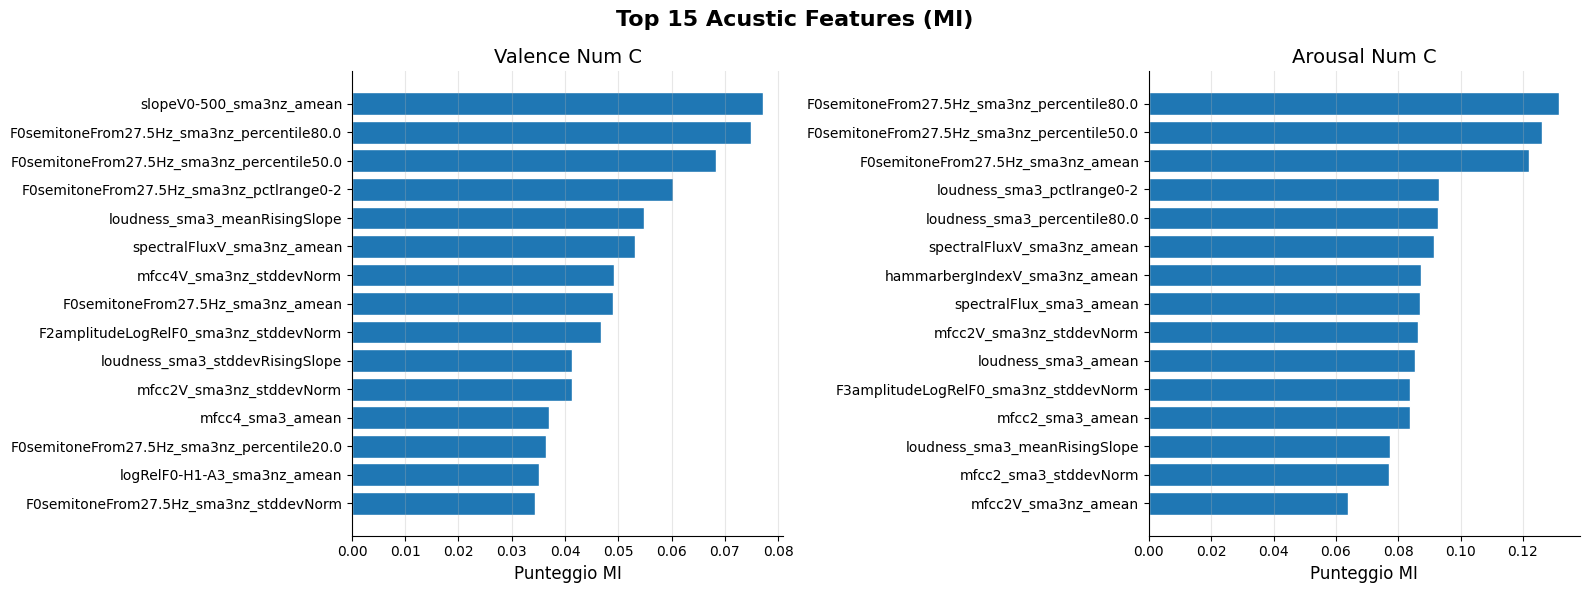

In [5]:
# Displaying extracted features
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Top 15 Acustic Features (MI)", fontsize=16, fontweight='bold')

for ax, target in zip(axes, TARGETS):
    top = results[target].head(TOP_N)

    ax.barh(top["feature"][::-1], top["MI"][::-1], edgecolor="white")
    ax.set_xlabel("Punteggio MI", fontsize=12)
    ax.set_title(target.replace("_", " ").title(), fontsize=14)
    ax.grid(axis="x", alpha=0.3)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

plt.tight_layout()

out_dir = os.path.dirname(feat_path) if os.path.dirname(feat_path) else '.'
plot_path = os.path.join(out_dir, "MI_TOP15_Regression.png")
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
print(f"Graph saved in: {plot_path}")

plt.show()

In [6]:
# Selecting principal features
top_val_features = results[TARGETS[0]].head(TOP_N)["feature"].tolist()
top_ar_features = results[TARGETS[1]].head(TOP_N)["feature"].tolist()
selected_feature = list(set(top_val_features + top_ar_features))

# Selecting ID and target columns
structural_columns = ["file_id"] + TARGETS
optimized_db = df[structural_columns + selected_feature].copy()
optimized_db[selected_feature] = optimized_db[selected_feature].fillna(optimized_db[selected_feature].median())

dataset_path = os.path.join(out_dir, "EMOVOME_TopFeatures_Regression_Dataset.csv")
optimized_db.to_csv(dataset_path, index=False)
print(f"Database saved in: {dataset_path}")

Database saved in: /content/drive/MyDrive/EMOVOME_TopFeatures_Regression_Dataset.csv
